# Basic EDA Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\Jing Xuan\Desktop\Y3S2\DSE3101\DSE3101 Group Project\hdb_with_amenities_macro.csv")

print("Shape of dataset:", df.shape)
print("\nColumn types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

Shape of dataset: (157821, 37)

Column types:
month                         object
town                          object
flat_type                     object
block                         object
street_name                   object
storey_range                  object
floor_area_sqm               float64
flat_model                    object
lease_commence_date            int64
remaining_lease               object
resale_price                 float64
quarter                       object
rpi                          float64
resale_price_real            float64
sora_3m                      float64
inflation_yoy                float64
real_interest_rate           float64
sora_3m_lag1                 float64
real_interest_rate_lag1      float64
lat                          float64
lon                          float64
nearest_train_line            object
nearest_train_dist_m         float64
nearest_train_name            object
dist_nearest_hawker_m        float64
nearest_hawker_name          

# Separate numerical VS categorical variables

In [2]:
# Numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Categorical columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", num_cols)
print("\nCategorical columns:", cat_cols)

Numeric columns: ['floor_area_sqm', 'lease_commence_date', 'resale_price', 'rpi', 'resale_price_real', 'sora_3m', 'inflation_yoy', 'real_interest_rate', 'sora_3m_lag1', 'real_interest_rate_lag1', 'lat', 'lon', 'nearest_train_dist_m', 'dist_nearest_hawker_m', 'dist_cbd_m', 'dist_nearest_primary_m', 'dist_nearest_park_m', 'dist_nearest_sportsg_m', 'dist_nearest_mall_m', 'dist_nearest_healthcare_m']

Categorical columns: ['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'flat_model', 'remaining_lease', 'quarter', 'nearest_train_line', 'nearest_train_name', 'nearest_hawker_name', 'primary_schools_1km', 'parks_1km', 'nearest_sportsg_name', 'nearest_mall_name', 'nearest_healthcare_name']


# Correlation Matrix

In [3]:
# Correlation matrix
corr = df[num_cols].corr()

print(corr)

                           floor_area_sqm  lease_commence_date  resale_price  \
floor_area_sqm                   1.000000             0.064707      0.601208   
lease_commence_date              0.064707             1.000000      0.359483   
resale_price                     0.601208             0.359483      1.000000   
rpi                             -0.048762             0.043578      0.342874   
resale_price_real                0.659545             0.360567      0.903435   
sora_3m                         -0.047625             0.033459      0.214163   
inflation_yoy                    0.015350             0.009378      0.056718   
real_interest_rate              -0.031869             0.004413      0.031199   
sora_3m_lag1                    -0.050968             0.036108      0.232446   
real_interest_rate_lag1         -0.016800            -0.002283     -0.035216   
lat                              0.153325             0.343685     -0.150799   
lon                             -0.00576

# Heatmap to visualise correlation

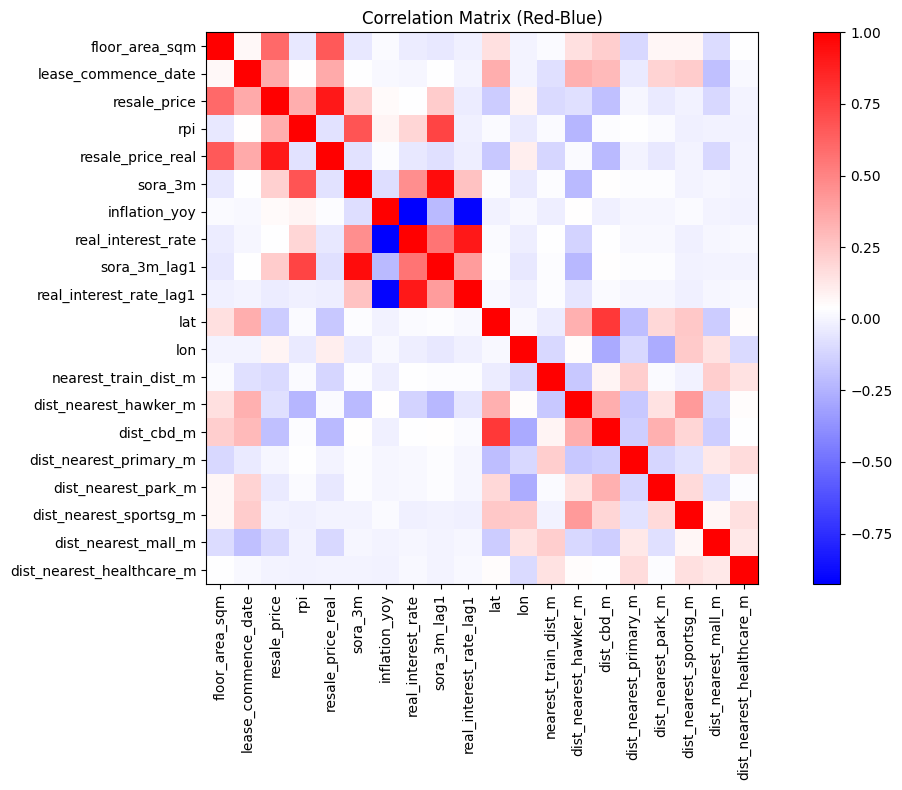

In [5]:
plt.figure(figsize=(12, 8))
plt.imshow(corr, cmap="bwr")  # 🔴🔵 red-blue

plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix (Red-Blue)")
plt.tight_layout()
plt.show()

# Correlation with target variable

In [6]:
target = "resale_price"

corr_target = corr[target].sort_values(ascending=False)

print("\nCorrelation with resale_price:")
print(corr_target)


Correlation with resale_price:
resale_price                 1.000000
resale_price_real            0.903435
floor_area_sqm               0.601208
lease_commence_date          0.359483
rpi                          0.342874
sora_3m_lag1                 0.232446
sora_3m                      0.214163
lon                          0.080620
inflation_yoy                0.056718
real_interest_rate           0.031199
dist_nearest_primary_m       0.007032
dist_nearest_healthcare_m   -0.006641
dist_nearest_sportsg_m      -0.008864
real_interest_rate_lag1     -0.035216
dist_nearest_park_m         -0.039415
dist_nearest_hawker_m       -0.079123
nearest_train_dist_m        -0.100150
dist_nearest_mall_m         -0.109694
lat                         -0.150799
dist_cbd_m                  -0.197101
Name: resale_price, dtype: float64


# Correlation with log(target variable)

In [9]:
import numpy as np

df["log_resale_price"] = np.log(df["resale_price"])

# Numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Correlation matrix
corr_log = df[num_cols].corr()

# Correlation with log price
corr_target_log = corr_log["log_resale_price"].sort_values(ascending=False)

print("Correlation with log(resale_price):")
print(corr_target_log)

Correlation with log(resale_price):
log_resale_price             1.000000
resale_price                 0.975639
resale_price_real            0.883369
floor_area_sqm               0.646173
lease_commence_date          0.400785
rpi                          0.363444
sora_3m_lag1                 0.248368
sora_3m                      0.235219
lon                          0.087084
inflation_yoy                0.081927
dist_nearest_sportsg_m       0.027384
real_interest_rate           0.016763
dist_nearest_healthcare_m   -0.008815
dist_nearest_park_m         -0.012719
dist_nearest_primary_m      -0.013358
dist_nearest_hawker_m       -0.033599
real_interest_rate_lag1     -0.055398
lat                         -0.092078
nearest_train_dist_m        -0.103922
dist_cbd_m                  -0.126925
dist_nearest_mall_m         -0.128105
Name: log_resale_price, dtype: float64


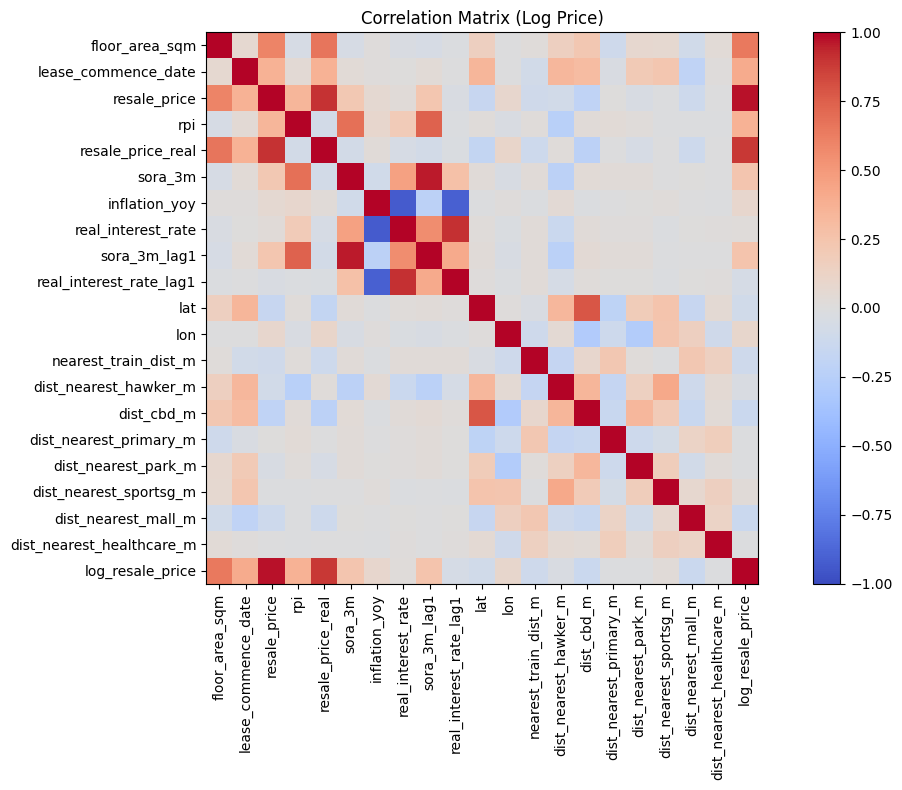

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(corr_log, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar()
plt.xticks(range(len(corr_log.columns)), corr_log.columns, rotation=90)
plt.yticks(range(len(corr_log.columns)), corr_log.columns)

plt.title("Correlation Matrix (Log Price)")
plt.tight_layout()
plt.show()

In [11]:
top_corr = corr_target_log.drop("log_resale_price")

print("\nTop positive correlations:")
print(top_corr.head(10))

print("\nTop negative correlations:")
print(top_corr.tail(10))


Top positive correlations:
resale_price              0.975639
resale_price_real         0.883369
floor_area_sqm            0.646173
lease_commence_date       0.400785
rpi                       0.363444
sora_3m_lag1              0.248368
sora_3m                   0.235219
lon                       0.087084
inflation_yoy             0.081927
dist_nearest_sportsg_m    0.027384
Name: log_resale_price, dtype: float64

Top negative correlations:
real_interest_rate           0.016763
dist_nearest_healthcare_m   -0.008815
dist_nearest_park_m         -0.012719
dist_nearest_primary_m      -0.013358
dist_nearest_hawker_m       -0.033599
real_interest_rate_lag1     -0.055398
lat                         -0.092078
nearest_train_dist_m        -0.103922
dist_cbd_m                  -0.126925
dist_nearest_mall_m         -0.128105
Name: log_resale_price, dtype: float64


# Distribution Plots

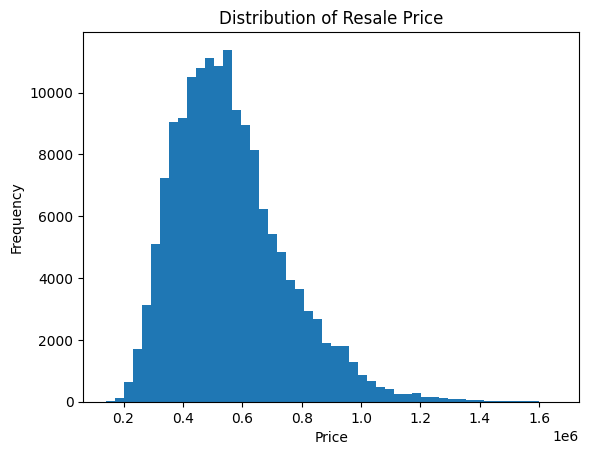

In [7]:
# Histogram of resale price
plt.figure()
plt.hist(df["resale_price"], bins=50)
plt.title("Distribution of Resale Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# Scatter Plots (relationships)

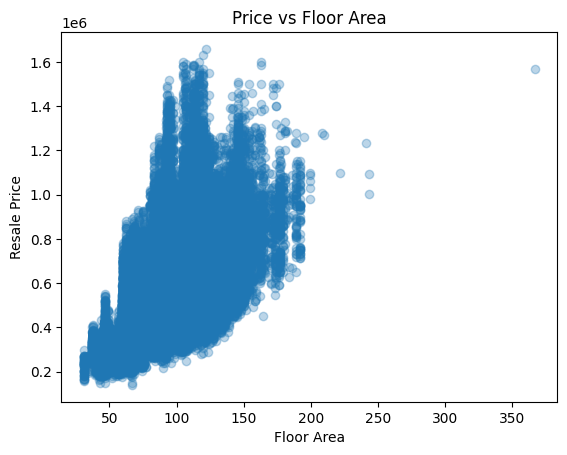

In [8]:
# Example: price vs floor area
plt.figure()
plt.scatter(df["floor_area_sqm"], df["resale_price"], alpha=0.3)
plt.xlabel("Floor Area")
plt.ylabel("Resale Price")
plt.title("Price vs Floor Area")
plt.show()